# Emotion trajectories: conversations drift toward positive valence at the close

日本語要約: 発話単位の感情ラベルを会話単位の時系列（感情の軌跡）として扱う。
ここではまず正解ラベルのみを使い、分類器の誤差を混ぜずにデータ自体の構造を見る。
感情→価数（バレンス）の写像を定義し、個々の会話の軌跡、正規化位置ごとの平均アーク
（ブートストラップ信頼帯付き）、感情間のマルコフ遷移行列、単一変化点検出器を示す。
会話の平均バレンスは終盤に向けて上昇し（別れ際の定型的なポジティブさ）、no_emotion と
happiness だけが「粘る」状態であることが分かる。遷移行列の行和が 1 になること、
合成データに埋めた感情シフトが正しい位置で検出されることを assert で確認する。

**What this notebook shows**

- A valence mapping from the seven emotion labels to numbers in
  {-1, 0, +1}, stated as the modeling choice it is.
- Per-dialogue emotion timelines with EWMA smoothing, on gold labels only,
  so everything here reflects the data rather than classifier error.
- The aggregate valence arc over all conversations, on a normalized 0-to-1
  position axis, with a bootstrap confidence band: valence rises sharply
  in the last tenth of a conversation.
- A first-order Markov transition matrix between emotions: `no_emotion`
  and `happiness` are sticky, everything else is transient (asserted
  row-stochastic).
- A single change-point detector for emotion shifts, validated on a
  synthetic dialogue with a planted shift (asserted position), then shown
  on real dialogues.

Most public work on this dataset stops at utterance classification. The
claim of this repository is that the conversation-level time series is
where VoC value lives, so this notebook establishes the trajectory
machinery on ground truth before notebook 03 stress-tests it under
predicted labels.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from voc_arc.data import EMOTIONS, load_dataset, repo_root
from voc_arc.plotting import (
    plot_arc_band,
    plot_dialogue_trajectory,
    plot_transition_heatmap,
    set_style,
)
from voc_arc.trajectory import (
    VALENCE,
    aggregate_arc,
    detect_shift,
    dialogue_valences,
    ewma,
    transition_matrix,
    valence_series,
)

set_style()
SEED = 42
CI = bool(os.environ.get("CI"))
N_BOOT = 100 if CI else 500
EWMA_ALPHA = 0.4

df, source = load_dataset()
df = df.sort_values(["dialogue_id", "turn"]).reset_index(drop=True)
print(f"source={source}: {df['dialogue_id'].nunique()} dialogues, n_boot={N_BOOT}")

source=raw: 13117 dialogues, n_boot=500


## 1. From emotion labels to valence

The mapping below is a modeling choice, not a property of the data, and
every downstream number depends on it:

| valence | emotions | reasoning |
|---|---|---|
| +1 | happiness | unambiguously positive |
| 0 | no_emotion, surprise | no signal; surprise can be either polarity |
| -1 | anger, disgust, fear, sadness | negative affect |

Collapsing seven classes into three values discards real distinctions
(an angry customer and a sad customer need different responses). The
trade is made because valence is the quantity VoC dashboards track, it
makes trajectories of different dialogues comparable, and it is robust to
the rare-class weakness documented in notebook 01. Surprise at 0 is the
most debatable row; the transition matrix below keeps the full seven
classes precisely so that no information is lost at that layer.

In [2]:
pd.Series({EMOTIONS[k]: v for k, v in VALENCE.items()}, name="valence").to_frame()

,valence
no_emotion,0.0
anger,-1.0
disgust,-1.0
fear,-1.0
happiness,1.0
sadness,-1.0
surprise,0.0


## 2. Single-dialogue trajectories

Raw valence per utterance is a noisy square wave, so each trajectory is
smoothed with an EWMA (alpha = 0.4: the current utterance carries 40
percent of the weight, so a single mislabeled or sarcastic turn cannot
flip the smoothed curve on its own). The two examples are chosen
deterministically: the longest dialogues with high valence variance.

example dialogue ids: [2241, 6079]


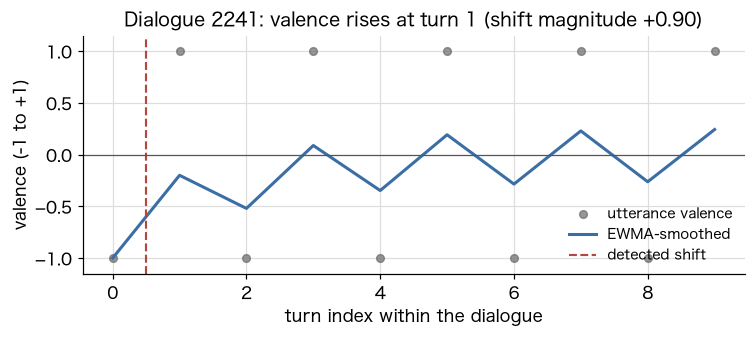

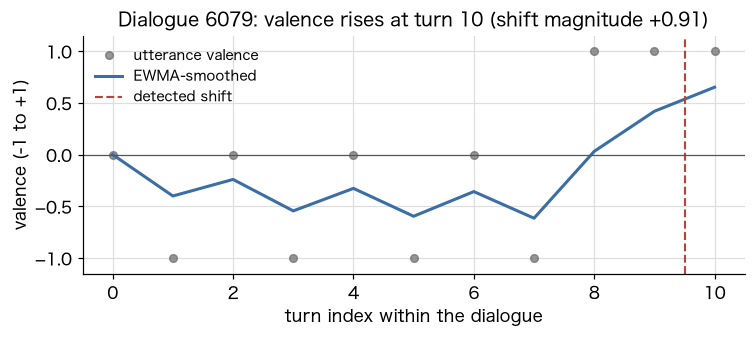

In [3]:
per_dialogue = {
    dialogue_id: group for dialogue_id, group in df.groupby("dialogue_id", sort=True)
}
volatility = {
    dialogue_id: float(valence_series(group["emotion"].to_numpy()).std())
    for dialogue_id, group in per_dialogue.items()
    if len(group) >= 10
}
examples = sorted(volatility, key=lambda d: (-volatility[d], d))[:2]
print(f"example dialogue ids: {examples}")

for dialogue_id in examples:
    group = per_dialogue[dialogue_id]
    valence = valence_series(group["emotion"].to_numpy())
    smoothed = ewma(valence, alpha=EWMA_ALPHA)
    shift_at, magnitude = detect_shift(valence, alpha=EWMA_ALPHA)
    direction = "rises" if magnitude > 0 else "falls"
    plot_dialogue_trajectory(
        valence,
        smoothed,
        title=(
            f"Dialogue {dialogue_id}: valence {direction} at turn {shift_at} "
            f"(shift magnitude {magnitude:+.2f})"
        ),
        shift_at=shift_at,
    )
    plt.tight_layout()

In [4]:
# The transcript behind the first example, for reading the arc against the text.
first = per_dialogue[examples[0]][["turn", "emotion_name", "text"]]
first.assign(text=first["text"].str.slice(0, 80)).set_index("turn")

,emotion_name,text
turn,,
0,anger,"Stupid girl , making me spend so much money , ..."
1,happiness,"Hello , welcome to Universal Bank . Please ins..."
2,anger,"I know where to put my card ! Stupid machine ,..."
3,happiness,Please input your 6 digit PIN code followed by...
4,anger,"Yeah , yeah , I know what I selected . Just gi..."
5,happiness,Please type the amount you would like to withd...
6,anger,"No , no ! Stupid machine , what are you doing ..."
7,happiness,Confirmed . Thank you for using our bank ! Ple...
8,anger,"No , no way ! What happened ? Give me my money !"


## 3. The aggregate arc: how an average conversation ends

Dialogues have different lengths, so each utterance is placed at a
normalized position in [0, 1] and averaged within ten position bins. The
confidence band resamples whole dialogues, not utterances: turns within a
conversation are dependent, and an utterance-level bootstrap would
pretend to more precision than the data has.

,position,mean,lo,hi
0,0.05,0.0533,0.0484,0.0583
1,0.15,0.0658,0.0589,0.0735
2,0.25,0.0654,0.0585,0.0721
3,0.35,0.0646,0.0572,0.0719
4,0.45,0.0638,0.0568,0.0711
5,0.55,0.0734,0.0668,0.0808
6,0.65,0.0776,0.0708,0.0848
7,0.75,0.0798,0.0724,0.0882
8,0.85,0.1291,0.1199,0.1387
9,0.95,0.2341,0.2259,0.2427


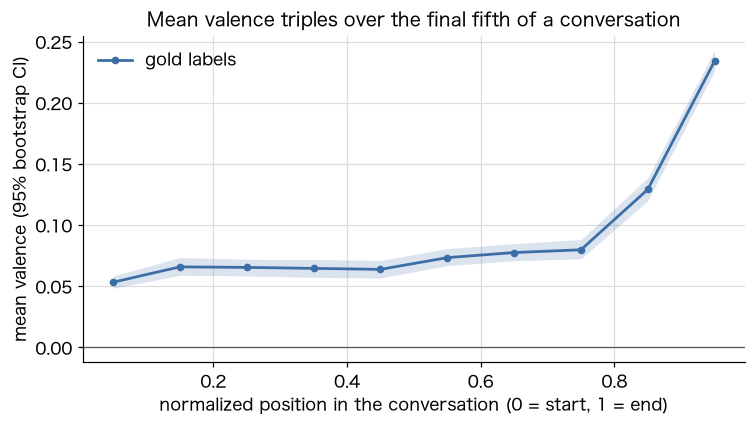

In [5]:
gold_arcs = dialogue_valences(df)
arc = aggregate_arc(gold_arcs, n_bins=10, n_boot=N_BOOT, seed=SEED)
ax = plot_arc_band(
    {"gold labels": arc},
    title="Mean valence triples over the final fifth of a conversation",
)
plt.tight_layout()
if source == "raw":  # keep the committed asset a full-corpus figure
    fig_path = repo_root() / "assets" / "valence_arc.png"
    fig_path.parent.mkdir(exist_ok=True)
    ax.figure.savefig(fig_path, dpi=150, bbox_inches="tight")
arc.round(4)

The arc is flat and mildly positive for most of a conversation, then
rises steeply in the last two bins. On the committed full-corpus run the
final bin's mean valence is more than four times the opening bin's.
The likely mechanism is unremarkable and worth stating plainly: closings
are ritualized ("great, thank you, see you then"), and the happiness
label concentrates there. Two readings for VoC practice:

- An end-of-call positivity spike is partly etiquette, not satisfaction.
  Measuring "did the conversation end well" against the corpus-wide arc
  is more informative than against zero.
- Deviations from the ritual (a conversation that ends flat or negative)
  are the interesting objects, which is what the shift detector below is
  for.

## 4. Emotion dynamics as a Markov chain

The transition matrix uses all seven labels (no valence collapse) and
counts transitions only within dialogues, never across dialogue
boundaries. Rows are conditional distributions, so each row must sum to
exactly one; that invariant is asserted, including for emotions that
never occur as a source state (they get a uniform row by construction).

row sums: [1. 1. 1. 1. 1. 1. 1.]


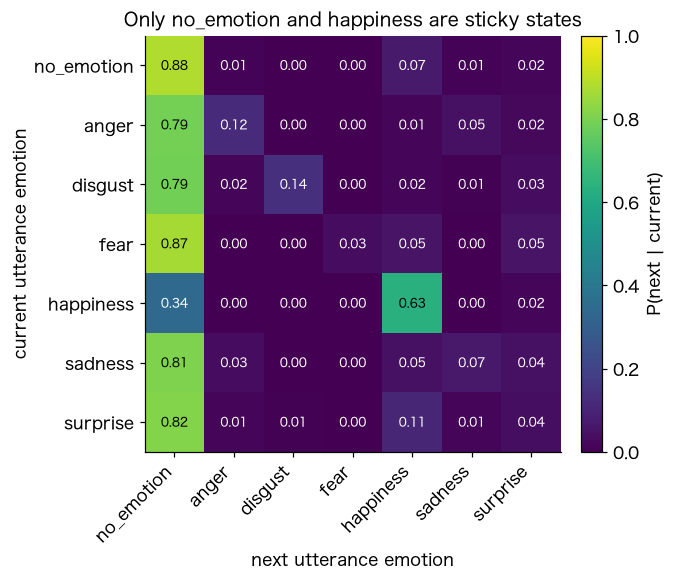

In [6]:
sequences = [group["emotion"].to_numpy() for group in per_dialogue.values()]
matrix = transition_matrix(sequences)
assert np.allclose(matrix.sum(axis=1), 1.0), "transition matrix rows must sum to 1"
print("row sums:", matrix.sum(axis=1).round(12))

plot_transition_heatmap(
    matrix,
    title="Only no_emotion and happiness are sticky states",
)
plt.tight_layout()

In [7]:
stickiness = pd.Series(np.diag(matrix), index=EMOTIONS, name="P(stay)").sort_values(
    ascending=False
)
stickiness.round(3).to_frame()

,P(stay)
no_emotion,0.883
happiness,0.634
disgust,0.139
anger,0.125
sadness,0.066
surprise,0.036
fear,0.032


The diagonal tells the dynamics story. `no_emotion` (about 0.88 on the
full corpus) and `happiness` (about 0.63) are the only states a
conversation tends to remain in; happiness is self-sustaining because a
pleasant exchange invites a pleasant reply. Anger persists only weakly
(about 0.13): in scripted dialogues, an angry turn is usually met with
de-escalation rather than symmetric anger. Fear, sadness and surprise are
almost purely transient, with most of their probability mass flowing
straight back to `no_emotion`. Surprise is the extreme case, which
matches its conversational role: it reacts to one turn and is resolved by
the next. A real contact-center corpus would likely show stickier anger;
this diagonal is a property of polite scripted small talk.

## 5. Shift detection, validated on a planted shift

The detector smooths the valence series and returns the split point that
maximizes the absolute difference between the mean after and the mean
before. Before trusting it on real dialogues, it must find a shift we
planted ourselves at a known position.

In [8]:
rng = np.random.default_rng(SEED)
flat = np.zeros(12)
planted = np.concatenate([flat, -np.ones(8)])  # neutral 12 turns, then negative
detected_at, magnitude = detect_shift(planted, alpha=1.0)
assert detected_at == 12, f"planted shift at 12, detected at {detected_at}"
assert magnitude == -1.0, f"expected magnitude -1.0, got {magnitude}"

noisy = planted + rng.normal(0, 0.15, planted.size)
detected_noisy, magnitude_noisy = detect_shift(noisy, alpha=0.5)
assert abs(detected_noisy - 12) <= 2, f"noisy detection too far off: {detected_noisy}"
print(
    f"clean: index {detected_at}, magnitude {magnitude:+.2f} / "
    f"noisy: index {detected_noisy}, magnitude {magnitude_noisy:+.2f}"
)

clean: index 12, magnitude -1.00 / noisy: index 14, magnitude -0.85


On real dialogues, the largest negative shifts are the conversations a
VoC reviewer would want queued first: exchanges that started neutral or
friendly and deteriorated.

In [9]:
shift_rows = []
for dialogue_id, group in per_dialogue.items():
    valence = valence_series(group["emotion"].to_numpy())
    if len(valence) >= 6:
        index, magnitude = detect_shift(valence, alpha=EWMA_ALPHA)
        shift_rows.append((dialogue_id, len(valence), index, magnitude))
shifts = pd.DataFrame(shift_rows, columns=["dialogue_id", "turns", "shift_at", "magnitude"])
worst = shifts.nsmallest(3, "magnitude")
worst.round(2)

,dialogue_id,turns,shift_at,magnitude
1419,2243,13,1,-1.15
2063,3057,8,1,-1.09
0,5,9,1,-1.06


,emotion_name,text
turn,,
0,happiness,Hey daddy ! You look great today . I like your...
1,no_emotion,NO !
2,anger,I haven't even told you what it is yet !
3,no_emotion,"Okay , okay , what do you want ?"
4,no_emotion,Do you think I could borrow the car ? I ’ m go...
5,no_emotion,Um .. I don ’ t think so . I need the car toni...
6,anger,Egg ! I told you about it last week ! Smelly T...
7,no_emotion,Who's this Eric guy ?
8,no_emotion,Duh ! He's like the hottest and most popular g...


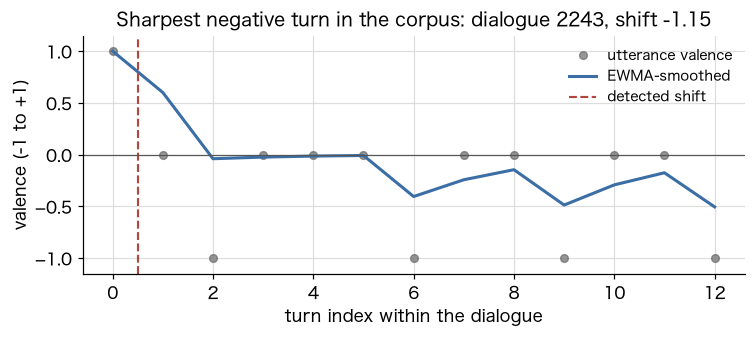

In [10]:
worst_id = int(worst.iloc[0]["dialogue_id"])
group = per_dialogue[worst_id]
valence = valence_series(group["emotion"].to_numpy())
shift_at, magnitude = detect_shift(valence, alpha=EWMA_ALPHA)
plot_dialogue_trajectory(
    valence,
    ewma(valence, alpha=EWMA_ALPHA),
    title=f"Sharpest negative turn in the corpus: dialogue {worst_id}, shift {magnitude:+.2f}",
    shift_at=shift_at,
)
plt.tight_layout()
group[["turn", "emotion_name", "text"]].assign(
    text=group["text"].str.slice(0, 80)
).set_index("turn")

## Limitations

- Every number here inherits the valence mapping; with surprise mapped to
  +1 (some VoC schemes do this) the late-arc rise would be steeper. The
  mapping is a three-line change in `voc_arc/trajectory.py` for anyone
  who wants the sensitivity check.
- DailyDialog conversations are scripted, short (median 8 turns) and
  polite. The closing-positivity ritual and the non-sticky anger are
  plausibly genre features; on real support calls the arc shape and the
  transition diagonal should be re-estimated, not assumed.
- The transition matrix is first-order and unconditional: it pools both
  speakers and all topics, and a Markov chain cannot represent
  longer-range structure (an apology working three turns later).
- The shift detector finds exactly one change point per dialogue and
  reports its strongest split even when the series is flat; magnitude
  filtering is the caller's responsibility.

## References

- Li, Su, Shen, Li, Cao, Niu. "DailyDialog: A Manually Labelled Multi-turn
  Dialogue Dataset." IJCNLP 2017.
- Reagan et al. "The emotional arcs of stories are dominated by six basic
  shapes." EPJ Data Science 2016 (the arc-aggregation framing).